#  Modelos logísticos con cosecha y métodos numéricos de orden 2

## Objetivos

1. Implementar métodos de orden 2:
   - **Explícitos:** Punto medio (RK2), RK2 generalizado con parámetro $\theta$ (cuadratura de 2 puntos), Taylor de orden 2.
   - **Implícitos:** Punto medio implícito, Taylor implícito de orden 2.
2. Implementar **Newton** para resolver las ecuaciones no lineales que aparecen en métodos implícitos.
3. Explorar **casos cualitativamente distintos** de los modelos de cosecha y comparar:
   - Extinción vs supervivencia (umbrales).
   - Dependencia con el paso $h$ (estabilidad / “artefactos” numéricos).
   - Preservación de positividad ($N(t)\ge 0$) y realismo físico.

In [51]:
# =========================
# Importaciones y utilidades
# =========================

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt


## 1. Modelos logísticos con cosecha

Sea $N(t)$ la densidad poblacional (peces). El crecimiento sin pesca se modela con la ecuación logística:

$$
N' = rN\left(1-\frac{N}{K}\right),
$$

donde:
- $r>0$ es la tasa intrínseca de crecimiento,
- $K>0$ es la capacidad de carga.

Los efectos de pesca (cosecha) se agregan con un término adicional. Consideraremos tres opciones:

1. **Cosecha constante**
$$
N' = rN\left(1-\frac{N}{K}\right) - H
$$

2. **Cosecha proporcional**
$$
N' = rN\left(1-\frac{N}{K}\right) - HN
$$

3. **Cosecha saturada** (tipo Michaelis–Menten)
$$
N' = rN\left(1-\frac{N}{K}\right) - H\frac{N}{A+N}
$$

donde $H>0$ y $A>0$ son constantes.

A continuación se implementa una interfaz para modelos autónomos que provee:

- `f(N)`: lado derecho $N' = f(N)$,
- `df(N)`: derivada $f'(N)$,
- `d2f(N)`: segunda derivada $f''(N)$,
- `equilibrios()`: lista de equilibrios (soluciones de $f(N)=0$).

> En esta práctica trabajaremos con ODEs autónomas (sin dependencia explícita en $t$), porque simplifica la derivación del método de Taylor:
$$
N'' = f'(N)\,f(N).
$$


In [52]:
# =========================
# Modelos (solución)
# =========================

@dataclass
class ModeloCosecha:
    '''
    Modelo autónomo de la forma N' = f(N) con parámetros del problema.

    Atributos
    
    nombre:
        Nombre descriptivo del modelo.
    parametros:
        Diccionario con parámetros (r, K, H, A, etc.).
    '''
    nombre: str
    parametros: Dict[str, float]

    def f(self, N: float) -> float:
        '''Evalúa f(N) en el modelo N' = f(N).'''
        raise NotImplementedError

    def df(self, N: float) -> float:
        '''Evalúa f'(N) (derivada respecto a N).'''
        raise NotImplementedError

    def d2f(self, N: float) -> float:
        '''Evalúa f''(N) (segunda derivada respecto a N).'''
        raise NotImplementedError

    def equilibrios(self) -> List[float]:
        '''
        Regresa los equilibrios (raíces reales) de f(N)=0.
        '''
        raise NotImplementedError


@dataclass
class CosechaConstante(ModeloCosecha):
    '''
    N' = rN(1 - N/K) - H
    '''
    def f(self, N: float) -> float:
        r = self.parametros["r"]
        K = self.parametros["K"]
        H = self.parametros["H"]
        return r*N*(1.0 - N/K) - H

    def df(self, N: float) -> float:
        r = self.parametros["r"]
        K = self.parametros["K"]
        return r - 2.0*(r/K)*N

    def d2f(self, N: float) -> float:
        r = self.parametros["r"]
        K = self.parametros["K"]
        return -2.0*(r/K)

    def equilibrios(self) -> List[float]:
        # Resolver rN(1 - N/K) - H = 0  =>  -(r/K)N^2 + rN - H = 0
        r = self.parametros["r"]
        K = self.parametros["K"]
        H = self.parametros["H"]

        a = -(r/K)
        b = r
        c = -H

        disc = b*b - 4*a*c
        eqs: List[float] = []
        if disc >= 0:
            s = float(np.sqrt(disc))
            for signo in (-1, 1):
                N = (-b + signo*s)/(2*a)
                if np.isfinite(N) and N >= 0:
                    eqs.append(float(N))

        eqs = sorted(set([round(x, 12) for x in eqs]))
        return eqs


@dataclass
class CosechaProporcional(ModeloCosecha):
    '''
    N' = rN(1 - N/K) - HN
    '''
    def f(self, N: float) -> float:
        r = self.parametros["r"]
        K = self.parametros["K"]
        H = self.parametros["H"]
        return r*N*(1.0 - N/K) - H*N

    def df(self, N: float) -> float:
        r = self.parametros["r"]
        K = self.parametros["K"]
        H = self.parametros["H"]
        return (r - H) - 2.0*(r/K)*N

    def d2f(self, N: float) -> float:
        r = self.parametros["r"]
        K = self.parametros["K"]
        return -2.0*(r/K)

    def equilibrios(self) -> List[float]:
        # N[(r-H) - (r/K)N] = 0
        r = self.parametros["r"]
        K = self.parametros["K"]
        H = self.parametros["H"]

        eqs = [0.0]
        if r > 0:
            Npos = K*(1.0 - H/r)
            if Npos > 0:
                eqs.append(float(Npos))
        return sorted(set([round(x, 12) for x in eqs]))


@dataclass
class CosechaSaturada(ModeloCosecha):
    '''
    N' = rN(1 - N/K) - H * N/(A + N)
    '''
    def f(self, N: float) -> float:
        r = self.parametros["r"]
        K = self.parametros["K"]
        H = self.parametros["H"]
        A = self.parametros["A"]
        return r*N*(1.0 - N/K) - H*(N/(A + N))

    def df(self, N: float) -> float:
        r = self.parametros["r"]
        K = self.parametros["K"]
        H = self.parametros["H"]
        A = self.parametros["A"]
        # Derivada de H*N/(A+N) es H*A/(A+N)^2
        return r - 2.0*(r/K)*N - H*(A/((A + N)**2))

    def d2f(self, N: float) -> float:
        r = self.parametros["r"]
        K = self.parametros["K"]
        H = self.parametros["H"]
        A = self.parametros["A"]
        # Segunda derivada: -2(r/K) + 2H*A/(A+N)^3
        return -2.0*(r/K) + 2.0*H*A/((A + N)**3)

    def equilibrios(self) -> List[float]:
        # f(N)=0 incluye N=0. Para N>0: r(1 - N/K) = H/(A+N)
        r = self.parametros["r"]
        K = self.parametros["K"]
        H = self.parametros["H"]
        A = self.parametros["A"]

        eqs = [0.0]

        # Coeficientes de: -r N^2 + r(K-A)N + rAK - HK = 0
        a = -r
        b = r*(K - A)
        c = r*A*K - H*K

        disc = b*b - 4*a*c
        if disc >= 0:
            s = float(np.sqrt(disc))
            for signo in (-1, 1):
                N = (-b + signo*s)/(2*a)
                if np.isfinite(N) and N > 0:
                    eqs.append(float(N))

        eqs = sorted(set([round(x, 12) for x in eqs]))
        return eqs


def describir_modelo(modelo: ModeloCosecha) -> None:
    '''
    Imprime una descripción rápida del modelo y sus equilibrios.
    '''
    print(f"Modelo: {modelo.nombre}")
    print(f"Parámetros: {modelo.parametros}")
    print(f"Equilibrios (aprox): {modelo.equilibrios()}")


## 2. Algoritmo de Newton (para métodos implícitos)

En métodos implícitos, típicamente necesitamos resolver ecuaciones de la forma:

$$
G(z) = 0,
$$

donde $z$ representa el valor desconocido $N_{n+1}$.



### Ejercicio (Newton)
**Implementa** el método de Newton para funciones escalares:

- Entrada: función `G(z)`, derivada `dG(z)`, aproximación inicial `z0`, tolerancia, máximo de iteraciones.
- Salida: aproximación a la raíz y el número de iteraciones.

Incluye:
- criterio de paro por tolerancia,
- manejo básico si la derivada es muy pequeña.

#### Pseudocódigo (Newton)
```pseudocode
Entrada: G, dG, z0, tol, max_iter
z ← z0
para k = 1 hasta max_iter:
    si |dG(z)| es muy pequeño: detener (fallo)
    z_nuevo ← z - G(z)/dG(z)
    si |z_nuevo - z| < tol: regresar z_nuevo
    z ← z_nuevo
regresar z (última aproximación)
```


In [53]:
# =========================
# Newton 
# =========================

def newton(
    G: Callable[[float], float],
    dG: Callable[[float], float],
    z0: float,
    tol: float = 1e-12,
    max_iter: int = 50,
) -> Tuple[float, int, bool]:
    '''
    Método de Newton para encontrar una raíz de G(z)=0 (caso escalar).

    Parámetros
    -
    G:
        Función a la que queremos encontrarle una raíz.
    dG:
        Derivada de G.
    z0:
        Aproximación inicial.
    tol:
        Tolerancia para el criterio de paro |z_{k+1} - z_k| < tol.
    max_iter:
        Máximo número de iteraciones.

    Regresa
    -
    z:
        Aproximación de la raíz.
    k:
        Iteraciones realizadas.
    exito:
        True si convergió bajo el criterio de tolerancia; False en caso contrario.
    '''
    #TODO: Implementar el método de Newton para encontrar una raíz de G(z)=0.
    z = z0
    for k in range(max_iter):
        if abs(dG(z)) < 1e-12:
            return z, k, False
        z_new = z - G(z) / dG(z)
        if abs(z_new - z) < tol:
            return z_new, k+1, True
        z = z_new
    return z, max_iter, False


## 3. Métodos numéricos de orden 2

En esta práctica implementaremos:

### 3.1 Métodos explícitos

1. **Punto medio (explícito)**  
$$
k_1 = f(N_n),\qquad
k_2 = f\!\left(N_n + \frac{h}{2}k_1\right),\qquad
N_{n+1} = N_n + hk_2.
$$


2. **RK2 generalizado con parámetro $\theta$** (cuadratura de dos puntos)  
Sea $\theta \neq 0$:
$$
Y = N_n + \theta h f(N_n),
$$
$$
N_{n+1} = N_n + h\Big(1-\frac{1}{2\theta}\Big)f(N_n)
          + h\Big(\frac{1}{2\theta}\Big) f(Y).
$$

> Observación:  
> - Si $\theta=\tfrac12$, se obtiene el método de punto medio explícito.  
> - Si $\theta=1$, se obtiene el método de Heun (trapezoidal explícito).

3. **Taylor explícito de orden 2** (modelo autónomo $N'=f(N)$)
$$
N_{n+1} = N_n + h f(N_n) + \frac{h^2}{2}\, N''(t_n),
\qquad
N''(t_n)=f'(N_n)\,f(N_n).
$$

### 3.2 Métodos implícitos

1. **Punto medio implícito**  
$$
N_{n+1} = N_n + h\, f\!\left(\frac{N_n + N_{n+1}}{2}\right).
$$
Esto se reescribe como $G(z)=0$ con:
$$
G(z) = z - N_n - h f\!\left(\frac{N_n+z}{2}\right).
$$

2. **Taylor implícito de orden 2 (backward Taylor)** (autónomo)  
Usando Taylor hacia atrás alrededor de $t_{n+1}$ se obtiene:
$$
N_{n+1} = N_n + h f(N_{n+1}) - \frac{h^2}{2} f'(N_{n+1}) f(N_{n+1}).
$$
De nuevo, $G(z)=0$ con:
$$
G(z) = z - N_n - h f(z) + \frac{h^2}{2} f'(z)f(z).
$$


### Ejercicio (Métodos de orden 2)
**Implementa** las funciones de un solo paso:

- `paso_punto_medio_explicito`
- `paso_rk2_theta` (con parámetro $\theta$)
- `paso_taylor2_explicito`
- `paso_punto_medio_implicito` (usando Newton)
- `paso_taylor2_implicito` (usando Newton)

En los implícitos, define claramente:
- la función $G(z)$,
- su derivada $G'(z)$,
- la elección de aproximación inicial.



#### Pseudocódigo (Punto medio explícito)
```pseudocode
Entrada: N_n, h, f
k1 ← f(N_n)
k2 ← f(N_n + (h/2) k1)
N_{n+1} ← N_n + h k2
```

In [54]:
def paso_punto_medio_explicito(Nn: float, h: float, f: Callable[[float], float]) -> float:
    '''
    Un paso del método de punto medio (explícito) para N' = f(N).
    Outputs:
    N_{n+1}:
        Aproximación de N en el siguiente paso de tiempo.
    '''
    k1 = f(Nn)
    k2 = f(Nn + (h/2) * k1)
    N_next = Nn + h * k2
    return N_next


#### Pseudocódigo (RK2-θ explícito)
```pseudocode
Entrada: N_n, h, f, θ
Y ← N_n + θ h f(N_n)
N_{n+1} ← N_n + h (1 - 1/(2θ)) f(N_n) + h (1/(2θ)) f(Y)
```


In [55]:

def paso_rk2_theta(Nn: float, h: float, f: Callable[[float], float], theta: float) -> float:
    '''
    Un paso del método RK2 generalizado con parámetro theta (explícito).
    Nota: requiere theta != 0.
    Outputs:
    N_{n+1}:
        Aproximación de N en el siguiente paso de tiempo.
    '''
    if abs(theta) < 1e-14:
        raise ValueError("theta no puede ser 0 en RK2-theta.")
    #TODO: Implementar el método RK2 generalizado con parámetro theta (explícito).
    Y = Nn + theta * h * f(Nn)
    N_next = Nn + h*(1 - 1/(2*theta))*f(Nn) + h*(1/(2*theta))*f(Y)
    return N_next


#### Pseudocódigo (Taylor2 explícito)
```pseudocode
Entrada: N_n, h, f, f'
Npp ← f'(N_n) * f(N_n)
N_{n+1} ← N_n + h f(N_n) + (h^2/2) Npp
```


In [56]:
def paso_taylor2_explicito(
    Nn: float,# Valor actual de N.
    h: float,# Paso de tiempo.
    f: Callable[[float], float],# Función que define el modelo N' = f(N).
    df: Callable[[float], float],# Derivada de f respecto a N.
) -> float:
    '''
    Un paso del método de Taylor explícito de orden 2 para un modelo autónomo N'=f(N).
    Usa N'' = f'(N) f(N).
    Outputs:
    N_{n+1}:
        Aproximación de N en el siguiente paso de tiempo.
    '''
    #TODO: Implementar el método de Taylor explícito de orden 2 para un modelo autónomo N'=f(N).
    Npp = df(Nn)*f(Nn)
    N_next = Nn + h*f(Nn) + (h**2/2)*Npp
    return N_next



#### Pseudocódigo (Punto medio implícito + Newton)
```pseudocode
Entrada: N_n, h, f, f'
Definir G(z)  = z - N_n - h f((N_n + z)/2)
Definir G'(z) = 1 - (h/2) f'((N_n + z)/2)
z0 ← N_n (o un predictor explícito)
N_{n+1} ← Newton(G, G', z0)
```


In [57]:
def paso_punto_medio_implicito(
    Nn: float, # Valor actual de N.
    h: float, # Paso de tiempo.
    f: Callable[[float], float], # Función que define el modelo N' = f(N).
    df: Callable[[float], float], # Derivada de f respecto a N.
    tol: float = 1e-12, # Tolerancia para el método de Newton.
    max_iter: int = 50, # Número máximo de iteraciones para el método de Newton.
) -> Tuple[float, int, bool]:
    '''
    Un paso del método de punto medio implícito para N'=f(N) usando Newton.
    Resuelve: z = Nn + h f((Nn + z)/2).   
    Outputs:
    z:
        Aproximación de N_{n+1}.
    iters:
        Iteraciones realizadas por Newton.  
    exito:  
        True si convergió bajo el criterio de tolerancia; False en caso contrario.
    '''
    #TODO: Implementar el método de punto medio implícito usando Newton para resolver z = Nn + h f((Nn + z)/2).
    
    def G(z):
        return z - Nn - h * f((Nn + z)/2)

    def dG(z):
        return 1 - (h/2) * df((Nn + z)/2)

    z0 = Nn
    N_next, iters, exito = newton(G, dG, z0, tol=tol, max_iter=max_iter)
    exito = iters < max_iter
    return N_next, iters, exito



#### Pseudocódigo (Taylor2 implícito + Newton)
```pseudocode
Entrada: N_n, h, f, f', f''
Definir G(z)  = z - N_n - h f(z) + (h^2/2) f'(z) f(z)
Definir G'(z) = 1 - h f'(z) + (h^2/2) [ f''(z) f(z) + (f'(z))^2 ]
z0 ← N_n (o un predictor explícito)
N_{n+1} ← Newton(G, G', z0)
```

In [63]:
def paso_taylor2_implicito(
    Nn: float,
    h: float,
    f: Callable[[float], float],
    df: Callable[[float], float],
    d2f: Callable[[float], float],
    tol: float = 1e-12,
    max_iter: int = 50,
) -> Tuple[float, int, bool]:
    '''
    Un paso del método de Taylor implícito de orden 2 (backward Taylor) usando Newton.
    Resuelve:
        z = Nn + h f(z) - (h^2/2) f'(z) f(z)
    Outputs:
    z:
        Aproximación de N_{n+1}.
    iters:
        Iteraciones realizadas por Newton.  
    exito:  
        True si convergió bajo el criterio de tolerancia; False en caso contrario.
    '''
    #TODO: Implementar el método de Taylor implícito de orden 2 usando Newton para resolver z = Nn + h f(z) - (h^2/2) f'(z) f(z).
    #TODO: Para esto, define las funciones G(z) y dG(z) necesarias para el método de Newton.
    def G(z: float) -> float:
        return z - Nn - h * f(z) + (h**2/2) * df(z) * f(z)


    def dG(z: float) -> float:
        return 1 - h*df(z) + (h**2/2)*(d2f(z)*f(z) + (df(z))**2)

    z0 = Nn
    N_next, iters, exito = newton(G, dG, z0, tol=tol, max_iter=max_iter)
    return N_next, iters, exito


## 4. Integración en malla uniforme

A continuación implementamos una función `integrar_autonoma` que:

- Reciba el modelo (con `f`, `df`, `d2f`), condiciones iniciales, paso $h$, número de pasos.
- Aplique un método de un paso (explícito o implícito).
- Regrese arreglos con tiempos y aproximaciones.

Incluye:
- un resumen básico del método,
- conteo de fallos de Newton (si aplica).



In [59]:
# =========================
# Integrador 
# =========================

def integrar_autonoma(
    modelo: ModeloCosecha,
    N0: float,
    t0: float,
    h: float,
    pasos: int,
    metodo: str,
    theta: float = 0.5,
    tol_newton: float = 1e-12,
    max_iter_newton: int = 50,
) -> Dict[str, np.ndarray]:
    '''
    Integra el modelo autónomo N' = f(N) usando un método seleccionado.

    Parámetros
    -
    modelo:
        Objeto con f, df, d2f.
    N0:
        Condición inicial N(t0)=N0.
    t0:
        Tiempo inicial.
    h:
        Paso.
    pasos:
        Número de pasos (se generan pasos+1 puntos).
    metodo:
        Opciones:
        - "pm_exp"   : punto medio explícito
        - "rk2_theta": RK2 generalizado (explícito)
        - "tay2_exp" : Taylor2 explícito
        - "pm_imp"   : punto medio implícito (Newton)
        - "tay2_imp" : Taylor2 implícito (Newton)
    theta:
        Parámetro para rk2_theta (si aplica).
    tol_newton, max_iter_newton:
        Parámetros de Newton en métodos implícitos.

    Regresa
    -
    dict con:
        "t": tiempos
        "N": aproximaciones
        "iters_newton": iteraciones de Newton (0 en métodos explícitos)
        "exitos_newton": 1 si Newton convergió, 0 si no (0 en métodos explícitos)
    '''
    f = modelo.f
    df = modelo.df
    d2f = modelo.d2f

    t = np.zeros(pasos + 1, dtype=float)
    N = np.zeros(pasos + 1, dtype=float)

    iters_newton = np.zeros(pasos + 1, dtype=int)
    exitos_newton = np.zeros(pasos + 1, dtype=int)

    t[0] = t0
    N[0] = N0

    for n in range(pasos):
        tn = t[n]
        Nn = N[n]
        t[n+1] = tn + h

        if metodo == "pm_exp":
            N[n+1] = paso_punto_medio_explicito(Nn, h, f)

        elif metodo == "rk2_theta":
            N[n+1] = paso_rk2_theta(Nn, h, f, theta=theta)

        elif metodo == "tay2_exp":
            N[n+1] = paso_taylor2_explicito(Nn, h, f, df)

        elif metodo == "pm_imp":
            z, iters, exito = paso_punto_medio_implicito(
                Nn, h, f, df, tol=tol_newton, max_iter=max_iter_newton
            )
            N[n+1] = z
            iters_newton[n+1] = iters
            exitos_newton[n+1] = int(exito)

        elif metodo == "tay2_imp":
            z, iters, exito = paso_taylor2_implicito(
                Nn, h, f, df, d2f, tol=tol_newton, max_iter=max_iter_newton
            )
            N[n+1] = z
            iters_newton[n+1] = iters
            exitos_newton[n+1] = int(exito)

        else:
            raise ValueError(f"Método desconocido: {metodo}")

    return {
        "t": t,
        "N": N,
        "iters_newton": iters_newton,
        "exitos_newton": exitos_newton,
    }


def resumen_simulacion(nombre: str, sol: Dict[str, np.ndarray]) -> None:
    '''
    Imprime un resumen corto de una simulación.
    '''
    N = sol["N"]
    print(f" {nombre} ")
    print(f"  N_final = {N[-1]:.6g}")
    print(f"  N_min   = {np.min(N):.6g}")
    print(f"  N_max   = {np.max(N):.6g}")
    if np.any(sol["exitos_newton"] > 0):
        ex = sol["exitos_newton"][1:]  # ignorar entrada 0
        it = sol["iters_newton"][1:]
        print(f"  Newton: éxitos = {np.sum(ex)}/{len(ex)} | iteraciones promedio = {np.mean(it[it>0]):.3g}")


## 5. Análisis cualitativo de los modelos (casos distintos)

En esta sección se pide **usar los métodos implementados** para analizar dinámicas cualitativamente diferentes.

> Repite cada experimento con varios pasos $h$ (por ejemplo $h=0.5, 0.2, 0.05$) y compara cómo cambian las conclusiones.



### Ejercicio 5A (Cosecha constante: umbral de extinción)
Para
$$
N' = rN\left(1-\frac{N}{K}\right) - H,
$$
se sabe que existe un **umbral crítico** $H_c = \frac{rK}{4}$:

- Si $0<H<H_c$, aparecen dos equilibrios positivos (uno estable y uno inestable).
- Si $H>H_c$, ya no hay equilibrio positivo y típicamente ocurre extinción.

**Tareas**
1. Usa parámetros $r=1, K=1$.
2. Considera:
   - Caso 1: $H=0.1$ (por debajo del umbral $H_c=0.25$), con $N_0$:
     - (a) arriba del equilibrio inestable,
     - (b) abajo del equilibrio inestable.
   - Caso 2: $H=0.3$ (por arriba del umbral), con varios $N_0$.
3. Simula y haz una grafica con los 5 métodos en una misma figura:
   - `pm_exp`, `rk2_theta`, `tay2_exp`, `pm_imp`, `tay2_imp`.
4. Repite con pasos distintos y responde:

**Preguntas de interpretación**
- ¿Se observa un “punto de no retorno” (umbral en $N_0$) en el Caso 1?
- ¿Qué métodos tienden a producir valores negativos de $N$ cuando $h$ es grande?
- ¿Los métodos implícitos permiten usar pasos más grandes sin inestabilidad? ¿A costa de qué (Newton)?

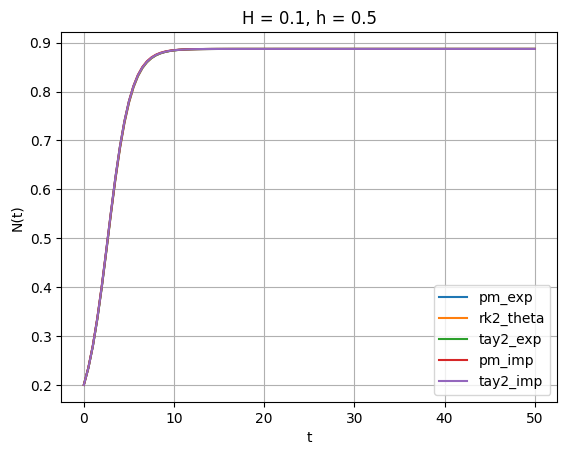

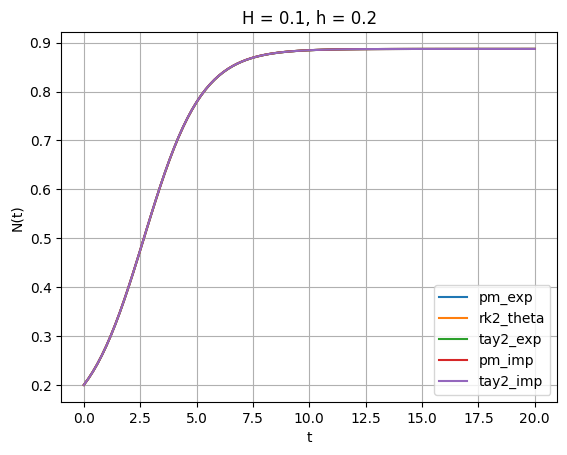

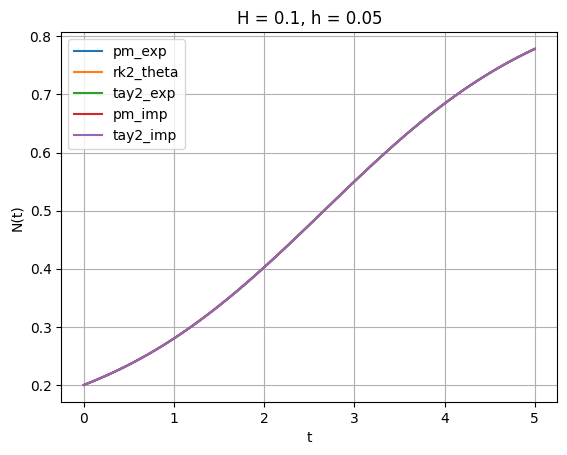

C:\Users\chac_\AppData\Local\Temp\ipykernel_21448\3476834124.py:11: RuntimeWarning: overflow encountered in scalar multiply
  return r*N*(1 - N/K) - H
C:\Users\chac_\AppData\Local\Temp\ipykernel_21448\867654900.py:13: RuntimeWarning: invalid value encountered in scalar multiply
  N_next = Nn + h*(1 - 1/(2*theta))*f(Nn) + h*(1/(2*theta))*f(Y)
C:\Users\chac_\AppData\Local\Temp\ipykernel_21448\2723537129.py:15: RuntimeWarning: overflow encountered in scalar multiply
  Npp = df(Nn)*f(Nn)


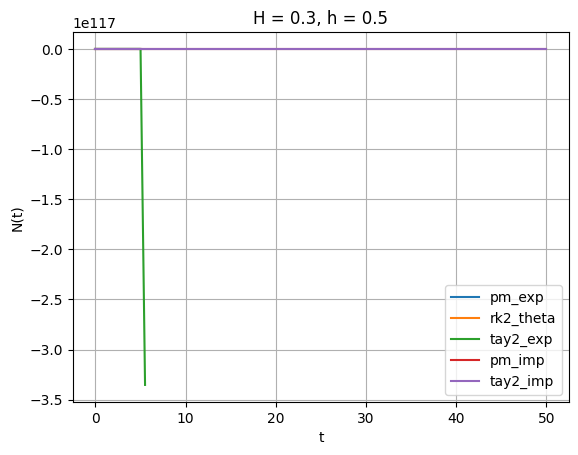

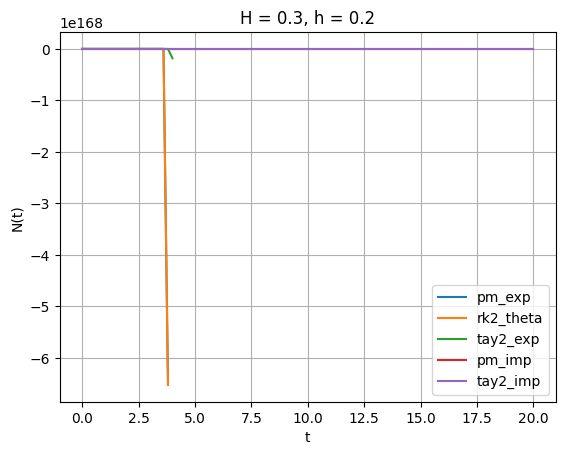

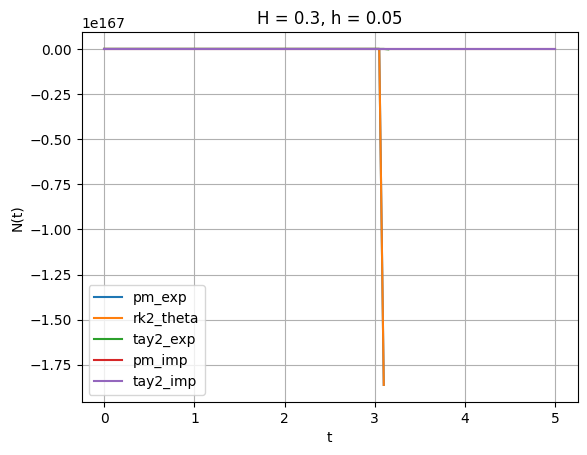

In [72]:
r = 1
K = 1
Hc = r*K/4

metodos = ["pm_exp", "rk2_theta", "tay2_exp", "pm_imp", "tay2_imp"]

for H in [0.1, 0.3]:
    modelo = ModeloCosecha("Modelo de cosecha constante", {"r": r, "K": K, "H": H})

    def f(N):
        return r*N*(1 - N/K) - H

    def df(N):
        return r - 2*(r/K)*N

    def d2f(N):
        return -2*(r/K)

    modelo.f = f
    modelo.df = df
    modelo.d2f = d2f

    for h in [0.5, 0.2, 0.05]:
        plt.figure()

        for metodo in metodos:
            sol = integrar_autonoma(
                modelo=modelo,
                N0=0.2,
                t0=0,
                h=h,
                pasos=100,
                metodo=metodo)

            t = sol["t"]
            N = sol["N"]

            plt.plot(t, N, label=metodo)

        plt.title(f"H = {H}, h = {h}")
        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.legend()
        plt.grid(True)

        plt.show()

### Ejercicio 5B (Cosecha proporcional: reducción efectiva de crecimiento)

Para
$$
N' = rN\left(1-\frac{N}{K}\right) - HN,
$$
se puede factorizar:
$$
N' = N\Big((r-H) - \frac{r}{K}N\Big).
$$

**Conclusión cualitativa esperada**
- Si $H<r$, existe un equilibrio positivo $N^* = K\left(1-\frac{H}{r}\right)$ (supervivencia).
- Si $H\ge r$, el único equilibrio no negativo es $N=0$ (extinción).

**Tareas**
1. Usa $r=1, K=1$.
2. Caso 1: $H=0.2$ (supervivencia), con distintos $N_0$.
3. Caso 2: $H=1.2$ (extinción), con distintos $N_0$.
4. Simula y haz una grafica con los 5 métodos en una misma figura:
   - `pm_exp`, `rk2_theta`, `tay2_exp`, `pm_imp`, `tay2_imp`.
5. Repite con pasos distintos y responde:

**Preguntas**
- ¿El equilibrio positivo se aproxima bien para $h$ grande?
- ¿Hay métodos que “crucen” a valores negativos de $N$?
- ¿Qué tan grande puede ser $h$ antes de ver comportamientos no físicos?

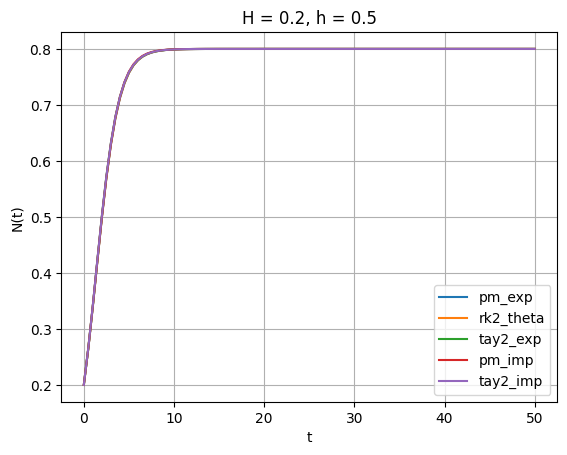

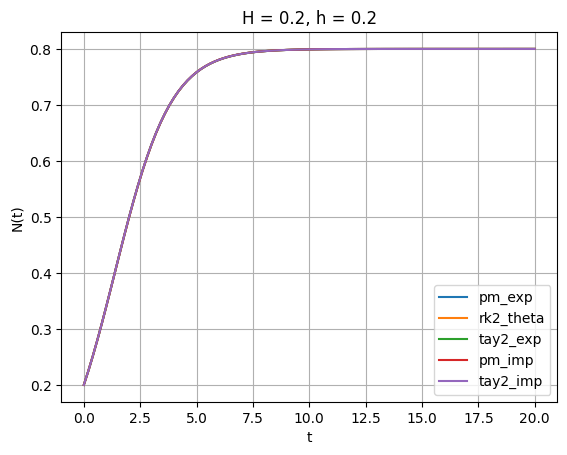

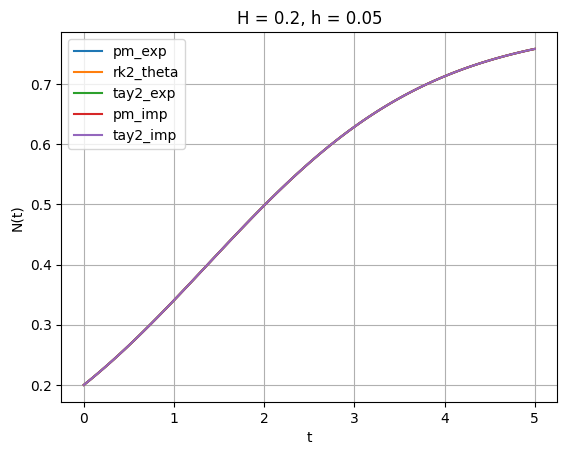

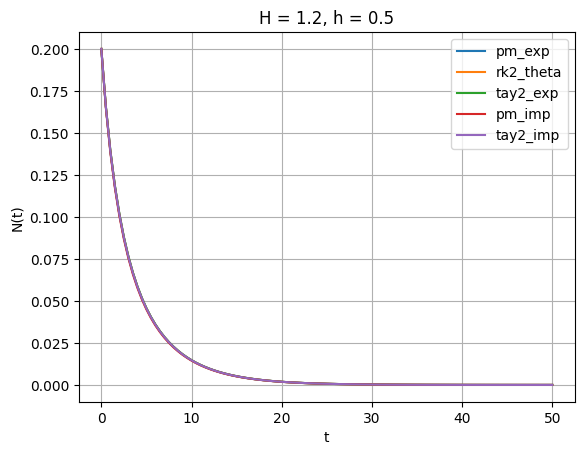

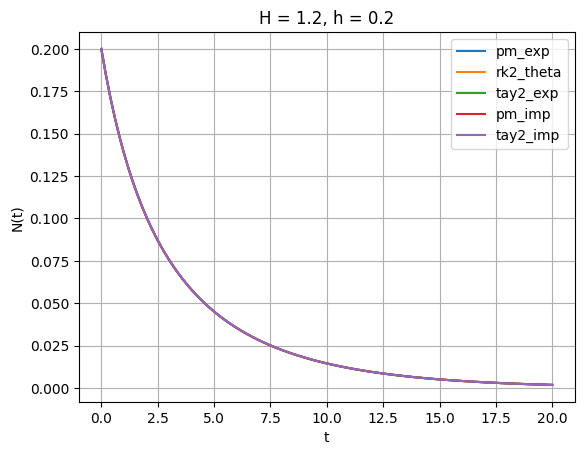

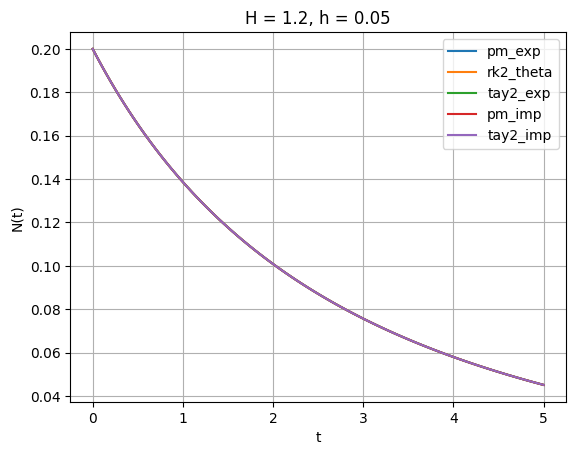

In [74]:
r = 1
K = 1
Hc = r*K/4

metodos = ["pm_exp", "rk2_theta", "tay2_exp", "pm_imp", "tay2_imp"]

for H in [0.2, 1.2]:
    modelo = ModeloCosecha("Modelo de cosecha constante", {"r": r, "K": K, "H": H})

    def f(N):
        return r*N*(1 - N/K) - H*N

    def df(N):
        return r - 2*(r/K)*N - H

    def d2f(N):
        return -2*(r/K)

    modelo.f = f
    modelo.df = df
    modelo.d2f = d2f

    for h in [0.5, 0.2, 0.05]:
        plt.figure()

        for metodo in metodos:
            sol = integrar_autonoma(
                modelo=modelo,
                N0=0.2,
                t0=0,
                h=h,
                pasos=100,
                metodo=metodo)

            t = sol["t"]
            N = sol["N"]

            plt.plot(t, N, label=metodo)

        plt.title(f"H = {H}, h = {h}")
        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.legend()
        plt.grid(True)

        plt.show()

### Ejercicio 5C (Cosecha saturada: bistabilidad y umbrales)

Para
$$
N' = rN\left(1-\frac{N}{K}\right) - H\frac{N}{A+N},
$$
pueden aparecer **dos equilibrios positivos** además de $N=0$, dependiendo de parámetros. Esto puede generar **bistabilidad**.

**Tareas**
1. Usa $r=1, K=1, A=0.1$.
2. Caso 1 (bistable): $H=0.2$.
3. Caso 2 (sin equilibrio positivo): $H=0.4$.
4. Para el caso bistable, simula con dos condiciones iniciales:
   - una pequeña (cerca de 0),
   - una grande (cerca de 1).
4. Simula y haz una grafica con los 5 métodos en una misma figura:
   - `pm_exp`, `rk2_theta`, `tay2_exp`, `pm_imp`, `tay2_imp`.
5. Repite con pasos distintos y responde:

**Preguntas**
- ¿Se observa un umbral claro en $N_0$ para $H=0.2$?
- Cerca del caso “crítico” (por ejemplo $H\approx 0.3$), ¿los métodos difieren más?
- ¿Qué método parece más robusto para pasos grandes?



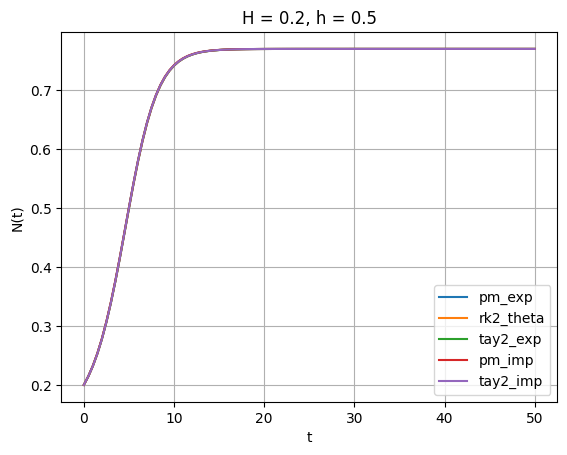

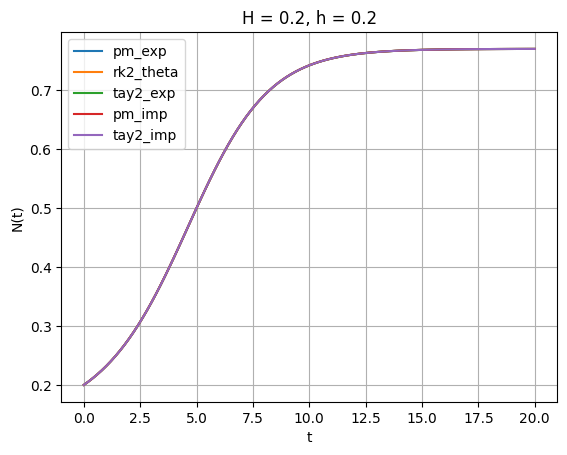

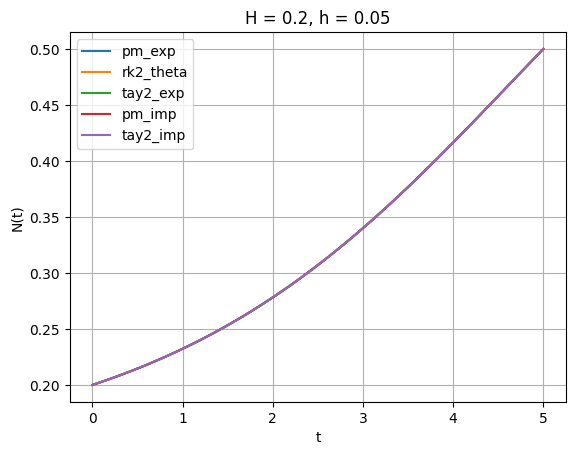

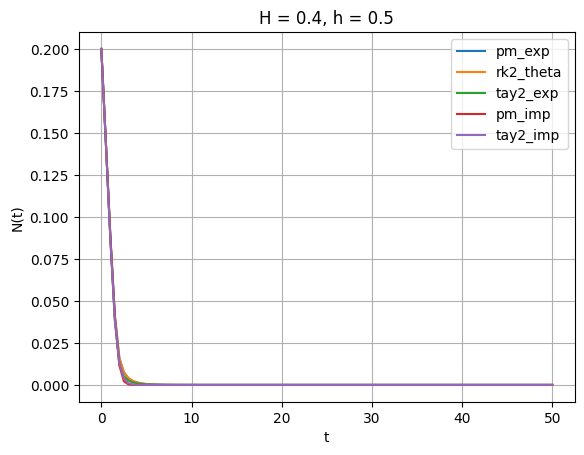

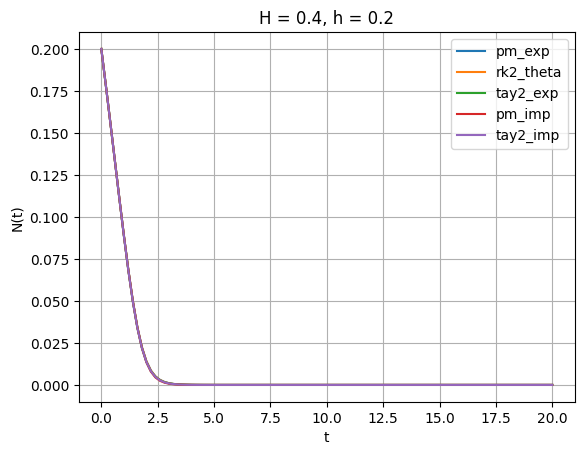

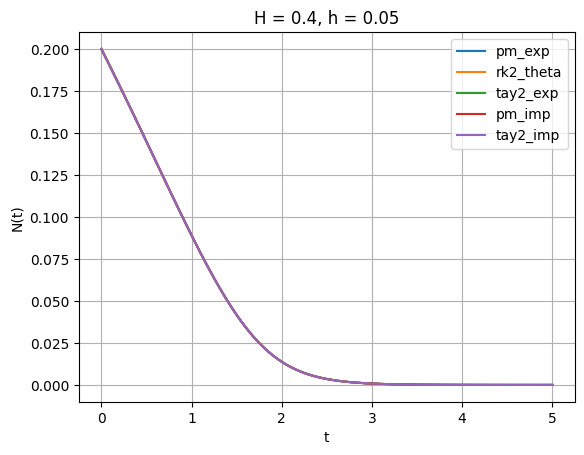

In [76]:
r = 1
K = 1
Hc = r*K/4
A = 0.1

metodos = ["pm_exp", "rk2_theta", "tay2_exp", "pm_imp", "tay2_imp"]

for H in [0.2, 0.4]:
    modelo = ModeloCosecha("Modelo de cosecha constante", {"r": r, "K": K, "H": H})

    def f(N):
        return r*N*(1 - N/K) - H*N*(1/(A + N))

    def df(N):
        return r - 2*(r/K)*N - (A*H)/((A + N)**2)

    def d2f(N):
        return -2*(r/K) + 2*H*A/((A + N)**3)

    modelo.f = f
    modelo.df = df
    modelo.d2f = d2f

    for h in [0.5, 0.2, 0.05]:
        plt.figure()

        for metodo in metodos:
            sol = integrar_autonoma(
                modelo=modelo,
                N0=0.2,
                t0=0,
                h=h,
                pasos=100,
                metodo=metodo)

            t = sol["t"]
            N = sol["N"]

            plt.plot(t, N, label=metodo)

        plt.title(f"H = {H}, h = {h}")
        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.legend()
        plt.grid(True)

        plt.show()